In [166]:
# importing required libraries/modules/packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat

In [167]:
url = '/content/drive/MyDrive/DA-ANB13/Python/Module-5/Module_End Assignment/social_media_engagement_5000.csv'

df = pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [169]:
# check the datasets for duplicate
df.duplicated().sum()

np.int64(0)

In [170]:
df['user_id'] = df['user_id'].astype(object)
df['user_id'].dtype

dtype('O')

# ❖	Task 2 — Data Cleaning

In [171]:
# identifying NaN values in Numerical columns

numerical_cols = ['age','likes','comments','shares']

for col in numerical_cols:
  df[col] = df[col].fillna(df[col].median())

print('After Imputing Numerical cols')

for col in numerical_cols:
  print(f'Total NaN values in {col} : {df[col].isnull().sum()}')

# converting numerical cols float to int for analyzing purpose

for col in numerical_cols:
  df[col] = df[col].astype(int)
  print(f'{col} column type : {df[col].dtype}')

After Imputing Numerical cols
Total NaN values in age : 0
Total NaN values in likes : 0
Total NaN values in comments : 0
Total NaN values in shares : 0
age column type : int64
likes column type : int64
comments column type : int64
shares column type : int64


In [172]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format = '%d-%m-%Y')
df['posted_at'].dtype

dtype('<M8[ns]')

In [173]:
# checking categorical columns

print(df['gender'].unique())
print(df['sentiment'].unique())

['Female' 'Male' 'Other' nan]
['negative' 'positive' 'neutral' nan]


In [174]:
# imputing calegorical colummns with mode

categorical_cols = ['gender','sentiment']

for col in categorical_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

print('After imputing')

for col in categorical_cols:
  print(f'{col} NaN value : {df[col].isnull().sum()}')
  print(f'{col} unique values : {df[col].unique()}')

After imputing
gender NaN value : 0
gender unique values : ['Female' 'Male' 'Other']
sentiment NaN value : 0
sentiment unique values : ['negative' 'positive' 'neutral']


In [175]:
# re-checking dataset for NaN values ater data cleaning
print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [176]:
# ■	Correct unrealistic values in likes, comments, shares

unrealistic_cols = ['likes','comments','shares']

for col in unrealistic_cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  IQR = q3 - q1
  lower_bound = q1 - 1.5 * IQR
  upper_bound = q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f'{col} unrealistic values : \n{outliers[col]}\n')


# There are no unrealistic values foud in likes, comments and shares column

likes unrealistic values : 
Series([], Name: likes, dtype: int64)

comments unrealistic values : 
Series([], Name: comments, dtype: int64)

shares unrealistic values : 
Series([], Name: shares, dtype: int64)



In [177]:
# ■	Extract hashtag count for each row / each post

df['hashtag_count'] = df['hashtags'].str.split().str.len()
print(df[['hashtags', 'hashtag_count']].head())



                hashtags  hashtag_count
0  #foodie #travel #love              3
1               #fitness              1
2                #foodie              1
3    #music #foodie #fun              3
4                #travel              1


In [178]:
# ■	Clean sentiment labels

df['sentiment'] = df['sentiment'].str.strip().str.title()
print(df['sentiment'].unique())

['Negative' 'Positive' 'Neutral']


# Inital EDA (Exploratory Data Analysis)

In [179]:
# ❖	Task 3 — Data Exploration using Pandas

# ●	View dataset structure using head(), tail(), shape, and columns.

print(f' First 5 rows :\n {df.head(5)}')
print(f'Last f 5 rows :\n {df.tail(5)}')
print(f'Shape of the dataset :\n {df.shape}')
print(f'Columns in the dataset :\n {df.columns}')

 First 5 rows :
   user_id  age  gender country  post_id post_type post_category  likes  \
0   25795   43  Female  Brazil   496713     image       fitness   7011   
1   10860   33    Male  Brazil   157326      reel          food  11750   
2   86820   32  Female      UK   109864      text          food   4862   
3   64886   51   Other  France   848877      text       fitness   5350   
4   16265   34   Other      UK   449706     image       fitness  12682   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0       354    1157            5726             44650 2022-12-17   
1      2606    1807            5947             80216 2023-06-02   
2       344     955            6946             44858 2023-05-07   
3      1083    1049             229             70455 2023-02-12   
4      2735    1300            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  Negati

In [180]:
#●	Check data types and info with info() and dtypes.

print(f'Information about the dataset : \n {df.info()}')
print(f'Data types of each column in dataset : {df.dtypes}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   object        
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [181]:
#●	Generate summary statistics using describe().

df.describe()

,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [182]:
# ●	Analyze categorical distributions using value_counts(), unique(), and nunique().


categorical_cols = df.select_dtypes('O').columns
categorical_cols

for col in categorical_cols:
    print(f'\n===== {col.upper()} =====')

    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))

    print("\nUnique Values:")
    print(df[col].unique())

    print("\nNumber of Unique Values:")
    print(df[col].nunique())


===== USER_ID =====

Value Counts:
user_id
74925    3
56163    3
19435    3
54535    2
25379    2
        ..
16540    1
99186    1
24288    1
23025    1
33411    1
Name: count, Length: 4862, dtype: int64

Unique Values:
[25795 10860 86820 ... 67021 29800 73400]

Number of Unique Values:
4862

===== GENDER =====

Value Counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Unique Values:
['Female' 'Male' 'Other']

Number of Unique Values:
3

===== COUNTRY =====

Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Unique Values:
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']

Number of Unique Values:
10

===== POST_TYPE =====

Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Unique Values:
['image

In [183]:
from pandas.core.arrays import numeric
# ●	Create a correlation matrix for numeric fields.

numerical_col = df.select_dtypes(include= ['number'])
correlation_matrix = numerical_col.corr()
correlation_matrix

#Possible insights:

#impression_count vs engagement_rate
#Correlation:  -0.23 - As impressions increase → engagement rate tends to decrease

# likes vs engagement_rate
# Correlation: ~ +0.09 - Slightly positive relationship, but not strong


# The correlation analysis reveals that most variables exhibit weak relationships, indicating that engagement metrics
# and user attributes operate largely independently. A notable exception is the negative correlation between impression
#  count and engagement rate, suggesting that higher reach does not necessarily translate into higher engagement efficiency.


,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093521,-0.002190
comments,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,0.008039,0.010139,0.093521,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319
hashtag_count,0.007173,0.007344,-0.002190,-0.015230,0.013379,-0.023301,-0.002714,0.008802,0.005319,1.000000


In [184]:
# ●	Perform groupby summaries by post_type, country, and sentiment.

# Average likes ny post type
print('Summarizing post_type vs likes')
df_avg_likes_posttype = df.groupby('post_type')['likes'].mean()
print(df_avg_likes_posttype,'\n')

# Average Impression by country
print('Summarizing Impression vs country')
avg_impr_country = df.groupby('country')['impression_count'].mean()
print(avg_impr_country)

Summarizing post_type vs likes
post_type
image    10104.852446
reel     10037.784879
text     10100.132530
video    10188.586122
Name: likes, dtype: float64 

Summarizing Impression vs country
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64


In [185]:
# gender wise engagement_rate
print('Summarizing engagement_rate vs gender')
df_gender_eng_rate = df.groupby('gender')['engagement_rate'].mean()
print(df_gender_eng_rate)



Summarizing engagement_rate vs gender
gender
Female    0.908307
Male      1.059003
Other     0.909324
Name: engagement_rate, dtype: float64


In [186]:
# engagement rate by country
print('Summarizing engagement_rate vs country')
df_eng_rate_country = df.groupby('country')['engagement_rate'].mean()
print(df_eng_rate_country)

Summarizing engagement_rate vs country
country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64


In [187]:
# engagement rate and follwer count by is_verified
print('Summarizing engagement_rate vs isverified')
df_eng_rate_isverified = df.groupby('is_verified')['engagement_rate'].mean()
print(df_eng_rate_isverified,'\n')

# followers count
print('Summarizing follower_count vs isverified')
df_follwers_isverifed = df.groupby('is_verified')['follower_count'].sum()
print(df_follwers_isverifed)

Summarizing engagement_rate vs isverified
is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64 

Summarizing follower_count vs isverified
is_verified
False    1784408497
True      184082627
Name: follower_count, dtype: int64


In [188]:
# summarizing avg watch time for post type
print('Summarizing average watch time vs post type')
df_avg_watch_posttype = df.groupby('post_type')['watch_time_sec'].mean()
print(df_avg_watch_posttype)

Summarizing average watch time vs post type
post_type
image    3881.448276
reel     4135.727202
text     4010.873092
video    4026.673469
Name: watch_time_sec, dtype: float64


In [189]:
# summarizing engagement rate vs post category
print('Summarizing engagement_rate vs post category')
df_eng_post_category = df.groupby('post_category')['engagement_rate'].mean()
print(df_eng_post_category)


Summarizing engagement_rate vs post category
post_category
education    0.844222
fashion      0.807109
fitness      0.865628
food         1.358628
lifestyle    1.091019
music        0.888803
tech         1.160475
travel       0.702223
Name: engagement_rate, dtype: float64


In [190]:
# summarizing hastags count vs post_category

print('Summarizing hastag count vs post_category')
df_sum_hastag_postCategory = df.groupby('post_category')['hashtags'].count()
print(df_sum_hastag_postCategory)


Summarizing hastag count vs post_category
post_category
education    631
fashion      594
fitness      675
food         593
lifestyle    607
music        635
tech         665
travel       600
Name: hashtags, dtype: int64


In [191]:
 # summarizing sentiment with lkes,share and comments

print('Summarizing likes vs sentiment')
df_sentiment_likes = df.groupby('sentiment')['likes'].mean()
print(df_sentiment_likes,'\n')

# summaring sentiment vs shares
print('Summarizing shares vs sentiment')
df_sentiment_shares = df.groupby('sentiment')['shares'].mean()
print(df_sentiment_shares,'\n')

# summarizing comments vs sentiment
print('Summarizing shares vs sentiment')
df_sentiment_comments = df.groupby('sentiment')['comments'].mean()
print(df_sentiment_comments)

Summarizing likes vs sentiment
sentiment
Negative    10208.081250
Neutral      9923.180092
Positive    10180.046956
Name: likes, dtype: float64 

Summarizing shares vs sentiment
sentiment
Negative    1007.307292
Neutral      996.565160
Positive    1005.086749
Name: shares, dtype: float64 

Summarizing shares vs sentiment
sentiment
Negative    1516.094792
Neutral     1528.404060
Positive    1480.650617
Name: comments, dtype: float64


In [192]:
# summarizing device_type vs engagement rate


print('Summarizing device type vs engagement rate')
df_eng_device_type = df.groupby('device_type')['engagement_rate'].mean()
print(df_eng_device_type)

Summarizing device type vs engagement rate
device_type
desktop    0.962006
mobile     1.123999
tablet     0.804560
Name: engagement_rate, dtype: float64


In [193]:
# summarizing on post type, country with engagement metrics


print('Summarizing country v, post type with engaement rate')
df_posttype_country = df.groupby(['country','post_type'])['engagement_rate'].mean()
print(df_posttype_country)

Summarizing country v, post type with engaement rate
country    post_type
Australia  image        0.892610
           reel         0.982071
           text         1.635716
           video        1.786939
Brazil     image        1.287089
           reel         0.460952
           text         3.187146
           video        1.264323
Canada     image        0.699746
           reel         0.545580
           text         0.643118
           video        1.710587
France     image        0.781962
           reel         1.075443
           text         0.825050
           video        1.936158
Germany    image        0.439610
           reel         1.186532
           text         0.790200
           video        0.640126
India      image        0.906345
           reel         0.425247
           text         0.555663
           video        0.809783
Japan      image        1.347596
           reel         0.607455
           text         0.566750
           video        0.651385
UA

In [194]:
# summaring comments for device_types and post_type

print('summaring comments for device_types and post_type')
df_comments_post_device = df.groupby(['device_type','post_type'])['comments'].sum()
print(df_comments_post_device)

summaring comments for device_types and post_type
device_type  post_type
desktop      image        692388
             reel         583906
             text         620077
             video        588356
mobile       image        583065
             reel         691188
             text         640479
             video        629911
tablet       image        626516
             reel         654778
             text         605831
             video        593704
Name: comments, dtype: int64


In [195]:
# summaring shares for sentiment and post_category

print('summaring comments for device_types and post_type')
df_shares_sentiment_category = df.groupby(['sentiment','post_category'])['shares'].sum()
print(df_shares_sentiment_category)

summaring comments for device_types and post_type
sentiment  post_category
Negative   education         99459
           fashion          107567
           fitness          128808
           food             120726
           lifestyle        135225
           music            130153
           tech             132414
           travel           112663
Neutral    education        186139
           fashion          166163
           fitness          206374
           food             197261
           lifestyle        187932
           music            195259
           tech             215157
           travel           167470
Positive   education        343159
           fashion          309889
           fitness          368200
           food             276674
           lifestyle        278465
           music            324885
           tech             323660
           travel           300851
Name: shares, dtype: int64


# ❖	Task 4 — Data Wrangling

In [196]:
# ●	Use merge, concat, or join if combining DataFrames.
# creating user data frame

user_df = df[['user_id', 'age', 'gender', 'country', 'follower_count', 'is_verified']].drop_duplicates()
user_df.head(5)

,user_id,age,gender,country,follower_count,is_verified
0,25795,43,Female,Brazil,81734,False
1,10860,33,Male,Brazil,5963,False
2,86820,32,Female,UK,501783,False
3,64886,51,Other,France,480212,False
4,16265,34,Other,UK,383936,False


In [197]:
# creating post data frame

post_df = df[['user_id', 'post_id', 'post_type', 'post_category',
              'likes', 'comments', 'shares',
              'impression_count', 'watch_time_sec', 'engagement_rate']]
post_df.head(5)

,user_id,post_id,post_type,post_category,likes,comments,shares,impression_count,watch_time_sec,engagement_rate
0,25795,496713,image,fitness,7011,354,1157,44650,5726,0.190862
1,10860,157326,reel,food,11750,2606,1807,80216,5947,0.201493
2,86820,109864,text,food,4862,344,955,44858,6946,0.137345
3,64886,848877,text,fitness,5350,1083,1049,70455,229,0.106195
4,16265,449706,image,fitness,12682,2735,1300,6019,4798,2.777372


In [198]:
# Merging two data frame user and post

merged_df = pd.merge(post_df, user_df, on='user_id', how='inner')
merged_df.head(5)

# The dataset was logically divided into user-level and post-level DataFrames and
# then recombined using a merge operation on the common key (user_id). This simulates
# real-world scenarios where data is stored across multiple tables.

,user_id,post_id,post_type,post_category,likes,comments,shares,impression_count,watch_time_sec,engagement_rate,age,gender,country,follower_count,is_verified
0,25795,496713,image,fitness,7011,354,1157,44650,5726,0.190862,43,Female,Brazil,81734,False
1,10860,157326,reel,food,11750,2606,1807,80216,5947,0.201493,33,Male,Brazil,5963,False
2,86820,109864,text,food,4862,344,955,44858,6946,0.137345,32,Female,UK,501783,False
3,64886,848877,text,fitness,5350,1083,1049,70455,229,0.106195,51,Other,France,480212,False
4,16265,449706,image,fitness,12682,2735,1300,6019,4798,2.777372,34,Other,UK,383936,False


In [199]:
# ●	Create new fields such as engagement_score, log-transformed metrics (optional), and hashtag count.

# Generating engagement scores for likes, comments and shares

df['engagement_score'] = (
    df['likes'] +
    2 * df['comments'] +
    3 * df['shares']
)

df[['likes','comments','shares','engagement_score']].head(5)

# An engagement score was created by assigning weights to likes, comments, and shares
# to better reflect user interaction intensity, with higher importance given to shares and comments.

# likes = 1, comments = 2, shares = 3

,likes,comments,shares,engagement_score
0,7011,354,1157,11190
1,11750,2606,1807,22383
2,4862,344,955,8415
3,5350,1083,1049,10663
4,12682,2735,1300,22052


In [200]:
# log-transformed metrics

# transforming skewed metrics so:
# extreme values don’t dominate
# patterns become easier to analyze

#Using log(1 + x) to avoid issues with zero values

# Transforming high variance columns : likes,comments,shares,impression_count, follower_count

df['log_likes'] = np.log1p(df['likes'])
df['log_comments'] = np.log1p(df['comments'])
df['log_impression'] = np.log1p(df['impression_count'])
df['log_follwers'] = np.log1p(df['follower_count'])

print(df[['likes','log_likes']].head(5))

# Log transformation was applied to skewed numerical features such as likes, comments,
# shares, impressions, and follower count to normalize their distribution and reduce the impact of extreme values.

   likes  log_likes
0   7011   8.855378
1  11750   9.371694
2   4862   8.489411
3   5350   8.585039
4  12682   9.448018


In [201]:
# Counting how many hashtags are present in each row.

df['hashtag_count'].describe()

,hashtag_count
count,5000.000000
mean,1.998600
std,0.812853
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,3.000000


# ❖	Task 5 — Statistical Analysis

In [202]:
# Compute descriptive stats for “likes, comments, shares, watch_time, engagement_rate, followers” columns:

df[['likes','comments','shares','watch_time_sec','engagement_rate','follower_count']].describe()

# Descriptive statistics were computed to summarize central tendency, dispersion, and distribution of key engagement metrics.

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
count,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,10106.982400,1502.039800,1002.9106,4014.503200,0.964356,393698.224800
std,5702.293022,856.393312,570.8552,2308.096459,5.318029,230927.884535
min,10.000000,0.000000,0.0000,0.000000,0.006363,87.000000
25%,5235.000000,792.000000,511.0000,2017.750000,0.145781,194480.000000
50%,10105.000000,1497.000000,1012.0000,4034.500000,0.253896,388982.000000
75%,14959.000000,2235.250000,1483.0000,6020.250000,0.504794,589744.250000
max,19998.000000,2999.000000,1999.0000,7998.000000,191.504348,799533.000000


# ❖	Task 6 — Data Visualization

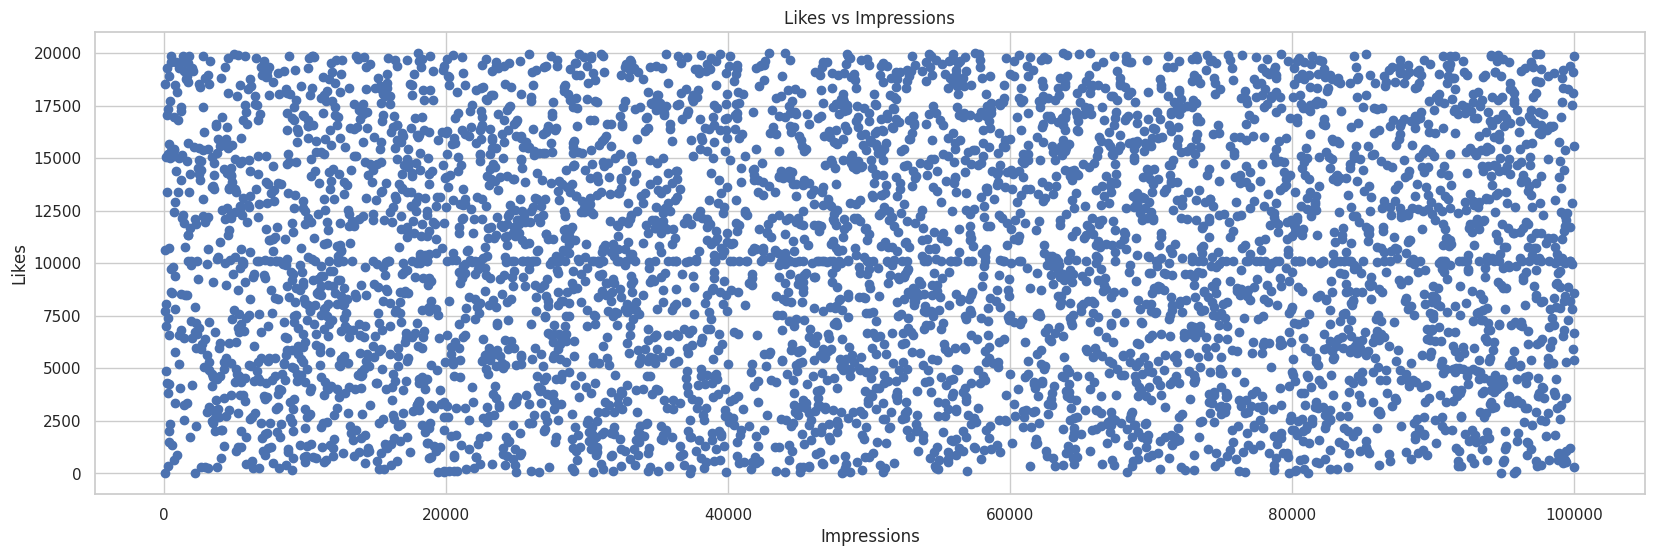

In [224]:
# # 1. Scatter: Likes vs Impressions
plt.figure(figsize=(20,6))
plt.scatter(df['impression_count'],df['likes'])
plt.title('Likes vs Impressions')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.show()



# Insights derived from likes vs impresssion visual:

* No strong linear relationship between impressions and likes
* High variability in likes at all impression levels
* High impressions do not consistently lead to higher likes
* Engagement is influenced by factors beyond reach (e.g., content quality)
* Likes appear weakly correlated or nearly independent of impressions overall

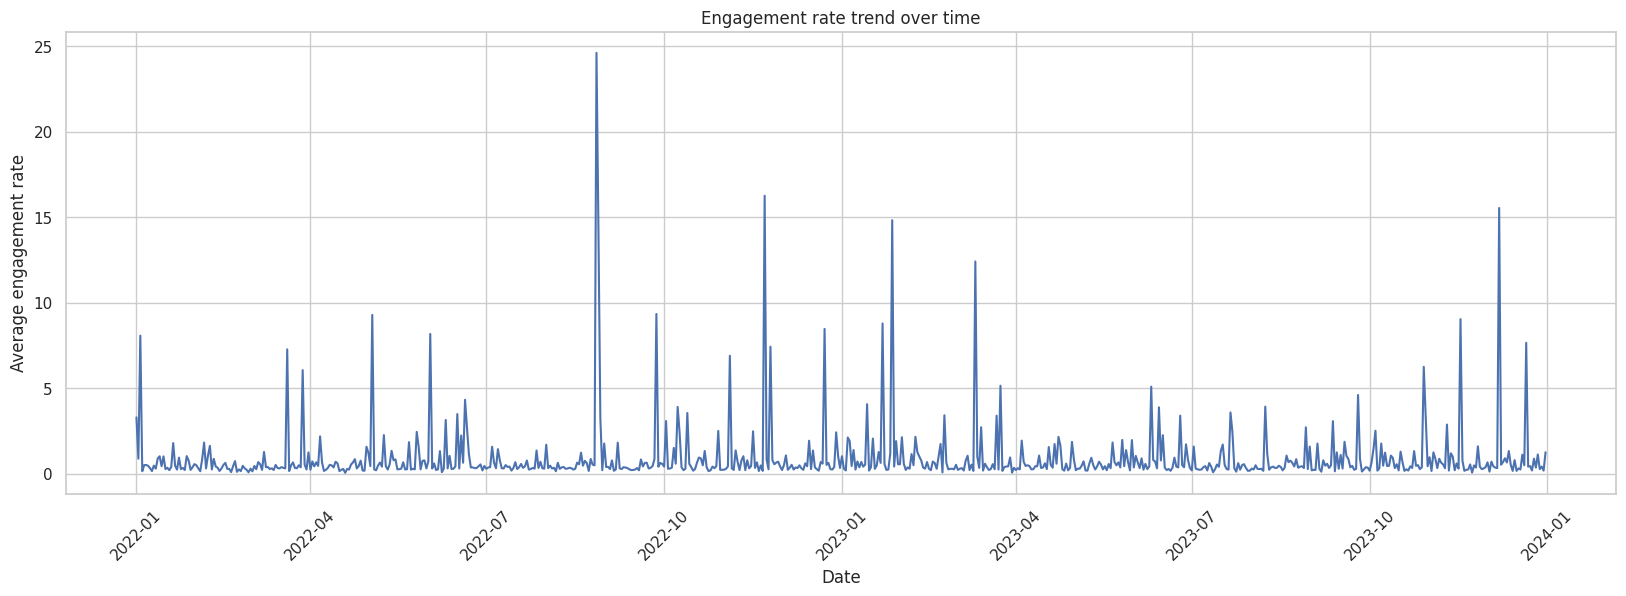

In [204]:
# 2. Line: Daily Engagement Trend

df['posted_at'] = pd.to_datetime(df['posted_at'])

daily_engagement = df.groupby('posted_at')['engagement_rate'].mean()

plt.figure(figsize = (20,6))

plt.plot(daily_engagement.index, daily_engagement.values)
plt.title('Engagement rate trend over time')
plt.xlabel('Date')
plt.ylabel('Average engagement rate')
plt.xticks(rotation = 45)
plt.show()

Insights derived for engagement rate trend over time:

 *   The highest recorded average engagement rate occurred in late Q3/early Q4 of 2022 (around August or September), where the rate surged to nearly 25. This represents a performance nearly 100 times higher than your typical baseline.

 *    There is a recurring pattern where significant engagement spikes occur roughly every 3 to 4 months. Notable peaks are visible around:
January/February 2022, August 2022 (The absolute peak),January 2023,March/April 2023,October/November 2023.
This could indicate seasonal interest, successful quarterly campaigns, or recurring holiday-related content that resonates better with your audience.

*   Despite the extreme spikes, the underlying trend is flat. The engagement rate does not show a steady long-term increase or decrease over the two-year period. This indicates that while  "hit" posts are very successful,  "standard" content hasn't seen a significant growth in its base engagement efficiency over time.







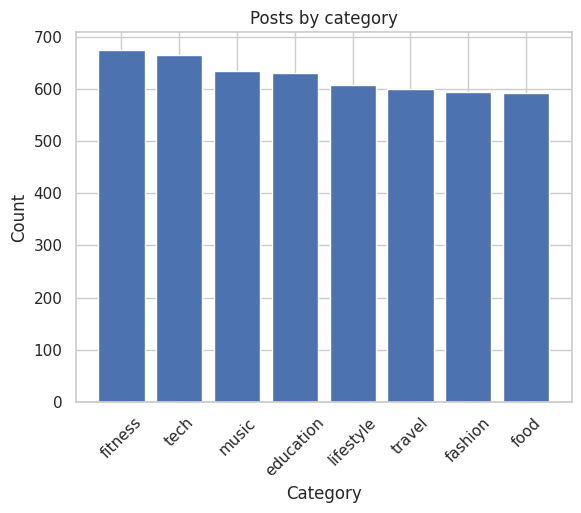

In [205]:
# 3. Bar: Posts by Category

category_count = df['post_category'].value_counts()
plt.figure()
plt.bar(category_count.index, category_count.values)
plt.title('Posts by category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

Insights derived for post by category vsiual:

1. High Content Volume in "Fitness" and "Tech"
The chart shows that Fitness and Tech are  most frequently posted categories, both exceeding 650 posts. This indicates that these are the "pillars" of  current content strategy.

2.The difference between the most frequent category (Fitness, ~675 posts) and the least frequent (Food/Travel, ~600 posts) is relatively small.This suggests a diversified content approach where no single topic completely dominates the feed, helping to appeal to a broad audience.

3.The Opportunity: Food has one of the lowest post counts (approx. 593), yet it has the highest average engagement rate (1.35).The Efficiency Gap: Fitness has the highest volume of posts, but its engagement rate is significantly lower (~0.86).


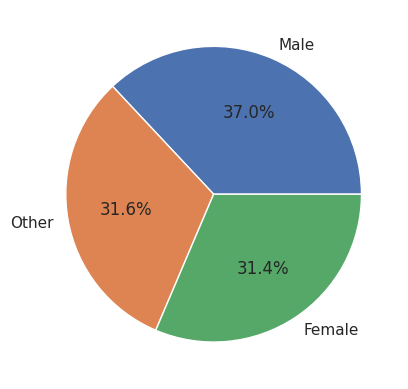

In [206]:
# 4. Pie: Gender Distribution

gender_count = df['gender'].value_counts()

plt.figure()
plt.pie(gender_count.values, labels = gender_count.index, autopct= '%1.1f%%')
plt.show()

Insights derived from gender distribution visual:

1. The most striking insight is how evenly distributed  audience is across the three categories.
Male: 37.0%
Other: 31.6%
Female: 31.4%
This indicates that the content has broad appeal and is not significantly skewed toward one specific gender. Most social media accounts tend to have a dominant group (e.g., 60%+ of one gender), but the profile is exceptionally balanced.

2. High Representation of "Other"
At 31.6%, the "Other" category represents nearly a third of the total audience.
Insight: This is a very significant demographic for the account. From a marketing perspective, it suggests that the content (particularly in categories like Tech and Fitness) is resonating with a diverse and inclusive community.

3. Male Users as the Leading Group
While the margins are slim, Male users are the largest demographic at 37%.Since the Male demographic is both your largest and most active group, they are currently your most valuable segment for driving likes and comments.




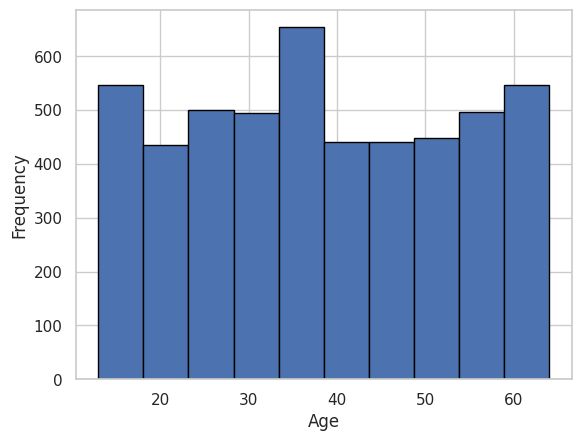

In [207]:
# 5. Histogram: Age Distribution
plt.figure()
plt.hist(df['age'], bins = 10, edgecolor = 'black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Insights derived from age distribution visual:

The histogram shows three distinct "peaks" (a multi-modal distribution), meaning the content resonates with three specific life stages:

* The Youth Surge (15–20 years): A strong initial peak representing Gen Z users.

* The Primary Core (35–40 years): The tallest bar in the histogram,         representing the largest and most active demographic.

* The Mature Segment (55–60 years): A significant resurgence among older users, which is less common for many social media profiles

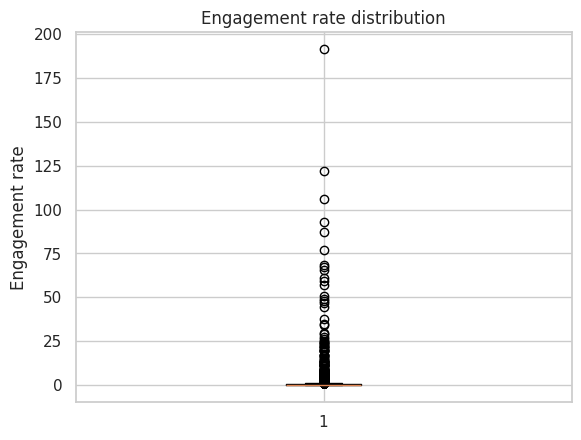

In [208]:
# 6. Box Plot: Engagement Rate
plt.figure()
plt.boxplot(df['engagement_rate'])
plt.title('Engagement rate distribution')
plt.ylabel('Engagement rate')
plt.show()


Insights derived from engagement rate distribution visual:
1. Presence of "Hyper-Viral" Outliers
The most prominent feature is the single outlier point at the top of the chart, reaching an engagement rate of ~191.This is an extreme anomaly. While the typical post gets very little traction, the visual had at least one "black swan" event where engagement was nearly 200 times higher than the median.

2. The "box" (representing the middle 50% of the data) is almost invisible at the very bottom of the Y-axis.This confirms that the vast majority of the content exists in a very low engagement bracket. According to the describe() table in Cell [16], 75% of the posts have an engagement rate below 0.50. On a scale that goes up to 200, these typical posts appear as a flat line at the zero mark.

3. The box plot visually explains why the "Average" is misleading. The extreme outliers are pulling the average up, making your performance look 4x better than it actually is for a "typical" post.



# ●	Seaborn visualization:

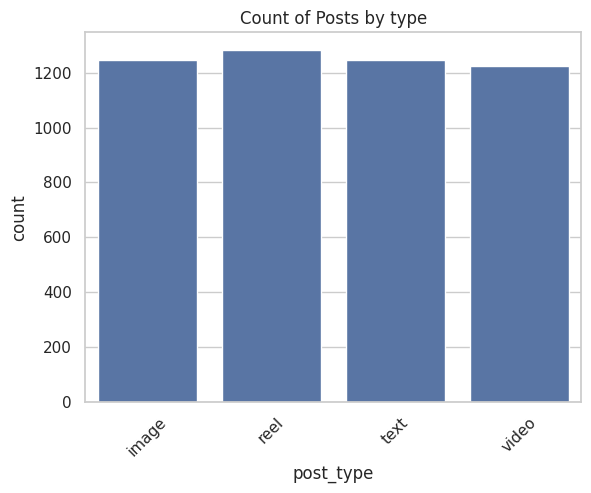

In [209]:
# 1.	Count plot: post type
sns.set(style="whitegrid")
plt.figure()
sns.countplot(data = df, x = 'post_type')
plt.title('Count of Posts by type')
plt.xticks(rotation = 45)
plt.show()


Insight derived from the visual for count of post by type:

* Post distribution is nearly equal across all types
* No single post type dominates the platform
* Content strategy appears balanced across formats
* Slight variation suggests minor preference for certain types

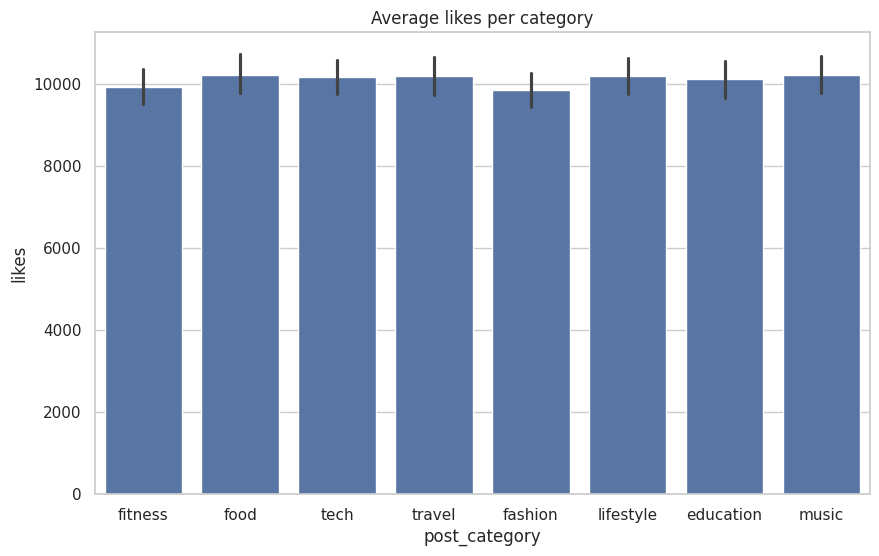

In [210]:
# 2. Bar Plot: Avg Likes by Category

plt.figure(figsize=(10,6))
sns.barplot(data = df, x ='post_category', y = 'likes', estimator='mean')
plt.title('Average likes per category')
plt.show()

Insights derived from visual for Average likes by post category:

* Average likes are very similar across categories
* No category significantly outperforms others
* Engagement is fairly uniform regardless of category
* Content topic has limited impact on likes

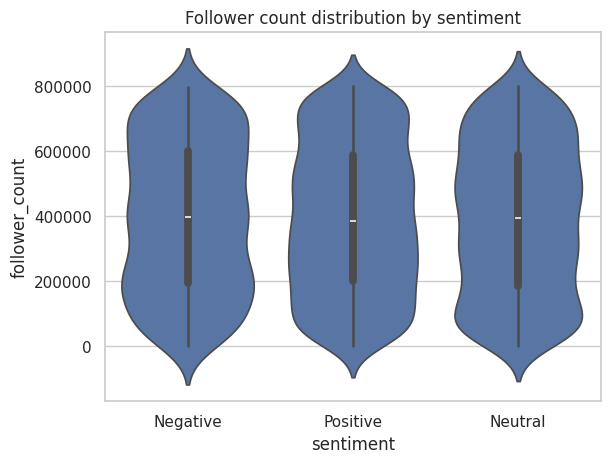

In [211]:
# 3. Violin Plot: Followers vs Sentiment

plt.figure()
sns.violinplot(data = df, x ='sentiment', y='follower_count')
plt.title('Follower count distribution by sentiment')
plt.show()

Insights derived from visual for follwers count by sentiment:

* Follower distribution is similar across all sentiments
* No sentiment group has a clear follower advantage
* Wide spread indicates high variability in followers
* Sentiment does not strongly influence audience size

In [212]:
# 4. Pair Plot: Numeric Features
plt.figure(figsize=(5,5))
numeric_cols = df.select_dtypes(include='number').columns

sns.pairplot(df[numeric_cols])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Insights derived for pair plot numeric features:

* Strong relationships exist among likes, comments, and shares
* Most other feature pairs show weak or no correlation
* Data points are widely scattered across combinations
* Engagement metrics are closely interconnected

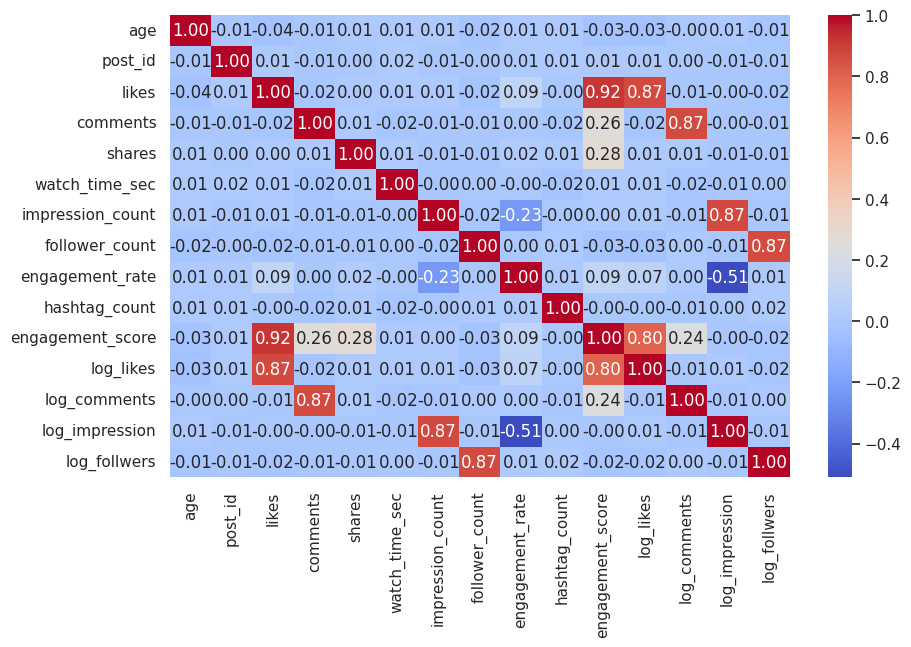

In [213]:
# 5. Heatmap: Correlation Matrix

plt.figure(figsize=(10,6))

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot= True, cmap = 'coolwarm', fmt='.2f')
plt.show()

Insights derived for heatmap from correlation matrix for numeric cols:

* Likes strongly correlate with engagement-related metrics
* Comments and shares also show strong positive correlation
* Most other variables have weak correlations
* Some negative correlation exists (e.g., impressions vs engagement rate)

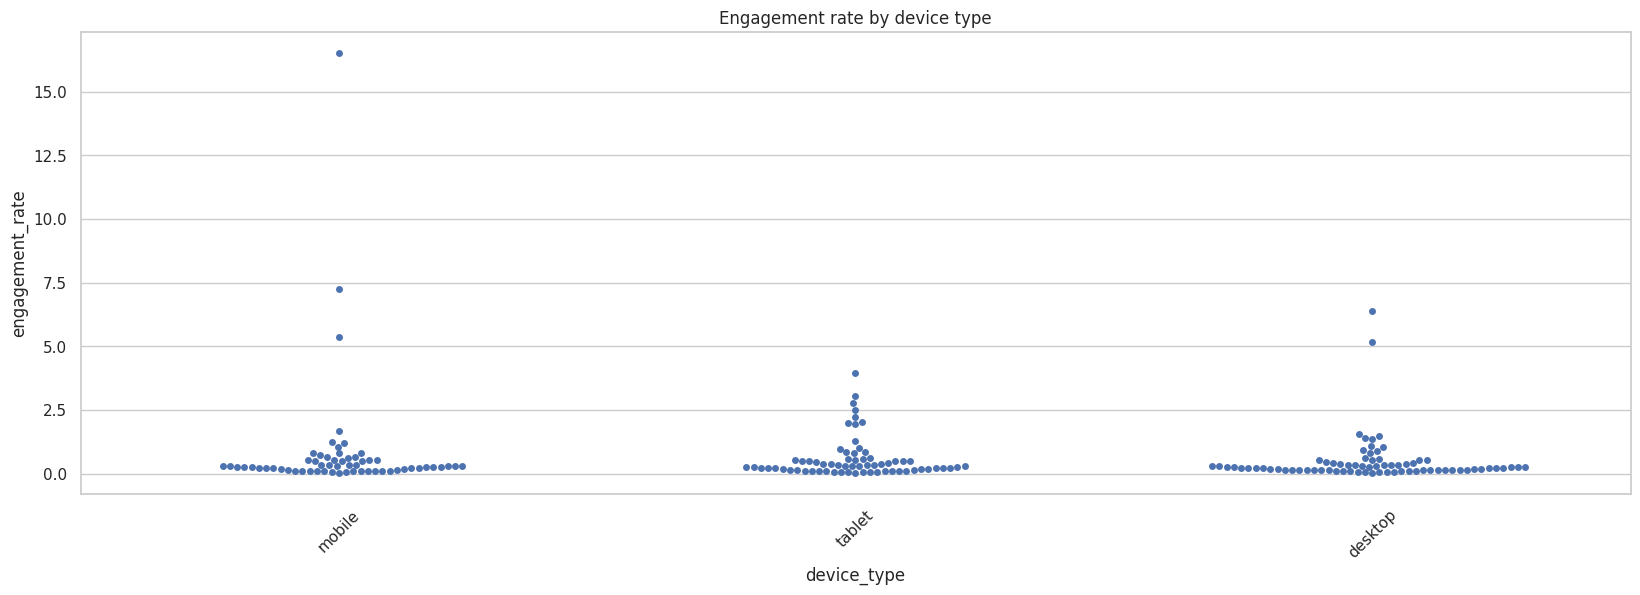

In [214]:
# 6. Swarm Plot: Engagement vs Device Type
plt.figure(figsize=(20,6))
 # using sample to avoid clutter
sns.swarmplot(data = df.sample(200), x ='device_type', y= 'engagement_rate')
plt.title('Engagement rate by device type')
plt.xticks(rotation = 45)
plt.show()



Insights derived from swarmplot visual for engagement rate by device type:

* Engagement rate is distributed similarly across device types
* No device shows a clear dominance in engagement
* High variability exists within each device category
* Device type has minimal impact on engagement rate

🔹 Content Performance  for One page report

In [215]:
# 1. Post type engagement
df.groupby("post_type")["engagement_rate"].mean()

,engagement_rate
post_type,
image,0.895646
reel,0.783047
text,1.064549
video,1.122365


In [216]:
# 2. Category performance
df.groupby("post_category")["engagement_rate"].mean()

,engagement_rate
post_category,
education,0.844222
fashion,0.807109
fitness,0.865628
food,1.358628
lifestyle,1.091019
music,0.888803
tech,1.160475
travel,0.702223


In [217]:
#3. Country performanc
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False).head(10)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [218]:
# 4. Age vs engagement
df[["age", "engagement_rate"]].corr()

,age,engagement_rate
age,1.000000,0.008039
engagement_rate,0.008039,1.000000


In [219]:
# 5. Verified vs non-verified
df.groupby("is_verified")["engagement_rate"].mean()

,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [220]:
# 6. Best time of day

df['hour'] = df['posted_at'].dt.hour
df.groupby("hour")["impression_count"].mean()

,impression_count
hour,
0,50013.7328


In [221]:
# 7. Device impact
df.groupby("device_type")["watch_time_sec"].mean()

,watch_time_sec
device_type,
desktop,3974.792521
mobile,4087.830760
tablet,3979.736429


In [222]:
# 8. Sentiment performance
df.groupby("sentiment")["engagement_rate"].mean()

,engagement_rate
sentiment,
Negative,1.038486
Neutral,0.991170
Positive,0.919744
